# 03 Baselines

This notebook records the shared baseline models used as reference points before the individual variants. The implementations live in `phase1/run_baselines.py`, and the saved results are loaded from `phase2/results/`.

## Baseline set
- **Popularity**: recommends the most frequent unseen apps from the training data.
- **UserCF**: recommends apps from similar users using normalized user interaction vectors.
- **SVD**: provides a latent-factor baseline from a truncated decomposition of the train interaction matrix.

These baselines establish the minimum comparison standard for the later EASE, RP3beta, and ItemKNN variants. The tables below rank the baselines on validation/test splits and then compare the retained advanced models against those anchors.

## Validation Baselines

,rank,model,precision@10,recall@10,ndcg@10,users_evaluated,eval_split
0,1,UserCF,0.039191,0.062940,0.079269,7568,val
1,2,Popularity,0.034567,0.057383,0.067148,7568,val
2,3,SVD,0.023163,0.030413,0.039400,7568,val


## Test Baselines

,rank,model,precision@10,recall@10,ndcg@10,users_evaluated,eval_split
0,1,UserCF,0.042754,0.063452,0.081960,7080,test
1,2,Popularity,0.037797,0.058550,0.071684,7080,test
2,3,SVD,0.022797,0.027715,0.038456,7080,test


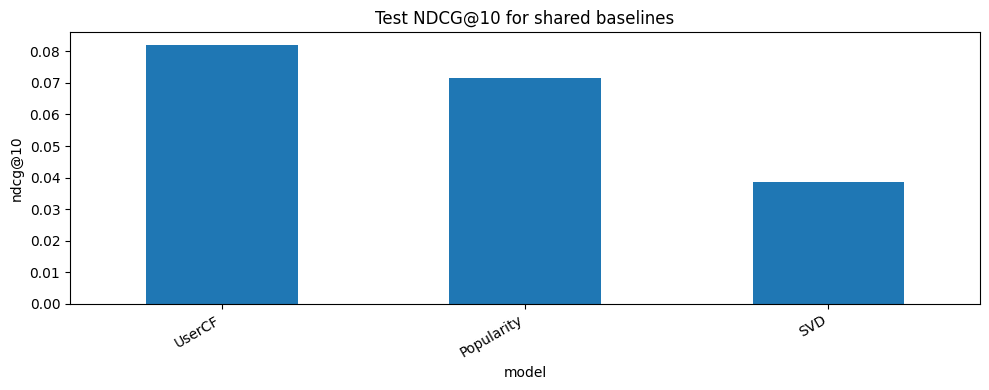

In [1]:
from IPython.display import display, Markdown

from analysis.shared_utils import load_baseline_results, metric_delta_table, plot_metric_bars, rank_models

baseline_val = load_baseline_results("val")
baseline_test = load_baseline_results("test")

display(Markdown("## Validation Baselines"))
display(rank_models(baseline_val, metric="ndcg@10"))

display(Markdown("## Test Baselines"))
display(rank_models(baseline_test, metric="ndcg@10"))

plot_metric_bars(baseline_test, metric="ndcg@10", title="Test NDCG@10 for shared baselines");

In [2]:
delta_vs_popularity = metric_delta_table(baseline_test, reference_model="Popularity")
delta_vs_usercf = metric_delta_table(baseline_test, reference_model="UserCF")

print("Delta versus Popularity on the test split")
display(delta_vs_popularity)

print("Delta versus UserCF on the test split")
display(delta_vs_usercf)

print(
    "Baseline takeaway:\n"
    "Popularity is the simplest reference point, UserCF is the strongest collaborative baseline, and SVD underperforms here."
)

Delta versus Popularity on the test split


,model,precision@10,recall@10,ndcg@10,precision@10_delta_vs_Popularity,recall@10_delta_vs_Popularity,ndcg@10_delta_vs_Popularity
0,Popularity,0.037797,0.058550,0.071684,0.000000,0.000000,0.000000
1,UserCF,0.042754,0.063452,0.081960,0.004958,0.004902,0.010276
2,SVD,0.022797,0.027715,0.038456,-0.015000,-0.030835,-0.033228


Delta versus UserCF on the test split


,model,precision@10,recall@10,ndcg@10,precision@10_delta_vs_UserCF,recall@10_delta_vs_UserCF,ndcg@10_delta_vs_UserCF
0,Popularity,0.037797,0.058550,0.071684,-0.004958,-0.004902,-0.010276
1,UserCF,0.042754,0.063452,0.081960,0.000000,0.000000,0.000000
2,SVD,0.022797,0.027715,0.038456,-0.019958,-0.035737,-0.043504


Baseline takeaway:
Popularity is the simplest reference point, UserCF is the strongest collaborative baseline, and SVD underperforms here.


In [3]:
from analysis.shared_utils import load_retained_results

retained_test = load_retained_results("test")
advanced_only = retained_test.loc[retained_test["model"].isin(["EASE-Binary-3000", "RP3beta-a0.9-b0.4-t400", "ItemKNN-BM25-K320"])].copy()
usercf_ndcg = retained_test.loc[retained_test["model"] == "UserCF", "ndcg@10"].iloc[0]
pop_ndcg = retained_test.loc[retained_test["model"] == "Popularity", "ndcg@10"].iloc[0]

advanced_only["ndcg_delta_vs_UserCF"] = advanced_only["ndcg@10"] - usercf_ndcg
advanced_only["ndcg_delta_vs_Popularity"] = advanced_only["ndcg@10"] - pop_ndcg

print("Advanced retained models versus the main baselines on the test split")
display(advanced_only.sort_values("ndcg@10", ascending=False))

Advanced retained models versus the main baselines on the test split


,model,precision@10,recall@10,ndcg@10,users_evaluated,eval_split,ndcg_delta_vs_UserCF,ndcg_delta_vs_Popularity
3,EASE-Binary-3000,0.044746,0.065984,0.086413,7080,test,0.004452,0.014729
4,RP3beta-a0.9-b0.4-t400,0.043121,0.064997,0.085032,7080,test,0.003072,0.013348
5,ItemKNN-BM25-K320,0.042994,0.063505,0.083244,7080,test,0.001284,0.011560
